<function healpy.visufunc.graticule(dpar=None, dmer=None, coord=None, local=None, fontsize=None, **kwds)>

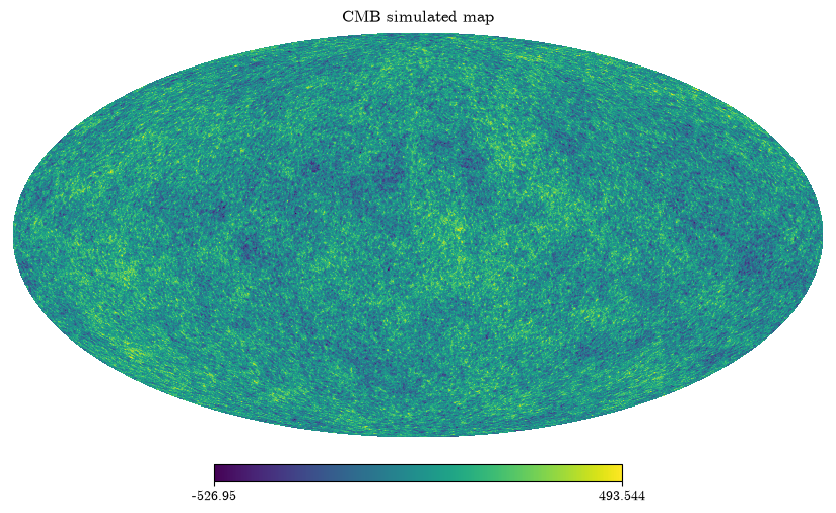

In [ ]:
import numpy as np
import healpy as hp

ell, Dl_TT = np.loadtxt('/Users/isaac/Documents/cmbstack/data/base_plikHM_TTTEEE_lowl_lowE_lensing.minimum.theory_cl', usecols=(0, 1), unpack=True)
ell = ell.astype(int)
lmax = ell.max()                      

# Convert D_ell -> C_ell  (uK^2)
Cl_TT_vals = 2.0 * np.pi * Dl_TT / (ell * (ell + 1.0))

# Build a full array indexed from ell=0, with 0,1 set to zero
Cl = np.zeros(lmax + 1)
Cl[ell] = Cl_TT_vals               # slot values at their true ell index
# Cl[0] = Cl[1] = 0.0  (already zero)

# Generate a Gaussian temperature map realization
nside = 1024
cmb_map = hp.synfast(Cl, nside=nside, lmax=lmax, new=True)  # in uK

hp.mollview(cmb_map,title='CMB simulated map')
hp.graticule

<function healpy.visufunc.graticule(dpar=None, dmer=None, coord=None, local=None, fontsize=None, **kwds)>

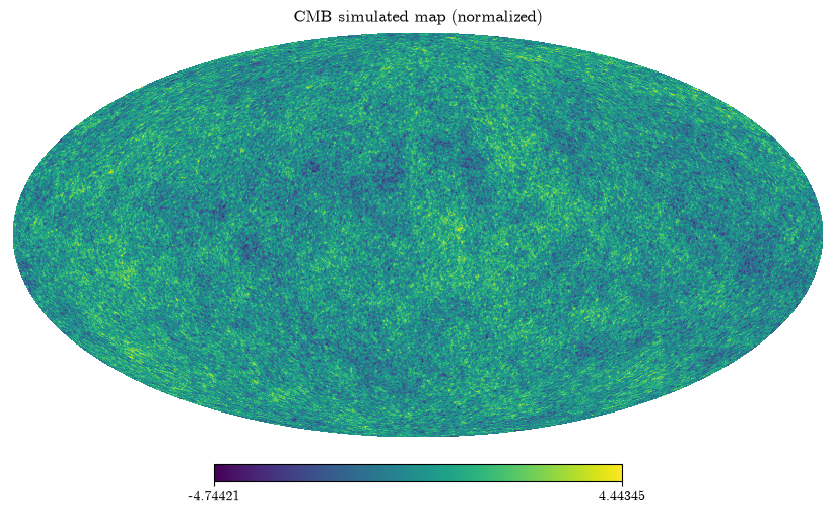

In [45]:
cmb_map_norm = hp.remove_monopole(cmb_map) / cmb_map.std()
hp.mollview(cmb_map_norm,title='CMB simulated map (normalized)')
hp.graticule

In [46]:
cmb_map_norm.std()

np.float64(1.0)

In [47]:
cmb_map_norm.mean()

np.float64(-2.7755575615628914e-17)